In [1]:
import numpy as np
from scipy.stats import binom, binomtest, beta
from scipy.special import betaln

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
np.random.seed(0)

true_rate = 0.11
baseline = 0.10

N = 500

data = np.random.binomial(1, true_rate, N)
print(data.sum())

# baseline = 0.5
# N = 98451
# data = np.zeros(N).astype(int)
# data[:49581] = 1

alpha_prior = 1
beta_prior = 9

63


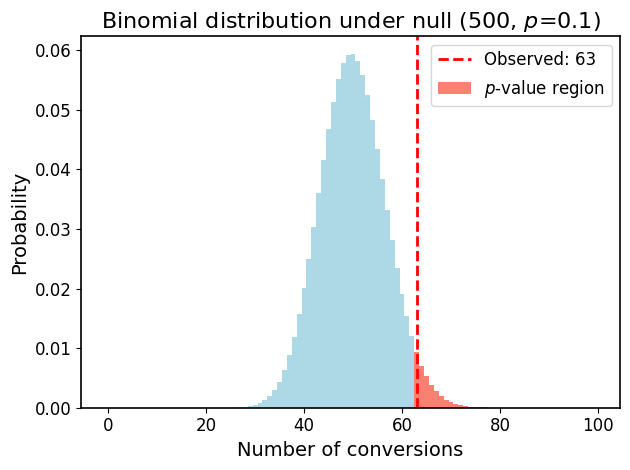

In [8]:
observed = data.sum()

x = np.arange(0, 100)

# Binomial PMF
pmf = binom.pmf(x, N, baseline)

# Plot the PMF
# plt.bar(x, pmf, color='lightblue', label='Binomial PMF', width=1)
plt.bar(x, pmf, color='lightblue', width=1)

# Mark observed value
plt.axvline(observed, color='red', linestyle='--', linewidth=2, label=f'Observed: {observed}')

# Shade tail for p-value (P(X >= observed))
tail_x = np.arange(observed, 100)
plt.bar(tail_x, pmf[observed:], color='salmon', label='$p$-value region', width=1)

plt.xlabel('Number of conversions')
plt.ylabel('Probability')
plt.title(f'Binomial distribution under null ({N}, $p$={baseline})')
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
def compute_test_stats(baseline, N, data, alpha_prior, beta_prior):
    n_conversions = data.sum()
    
    test = binomtest(n_conversions, N, baseline, alternative="greater")
    p_value = test.pvalue
    
    alpha_post = alpha_prior + n_conversions
    beta_post = beta_prior + N - n_conversions
    
    prob_better = 1 - beta.cdf(baseline, alpha_post, beta_post)
    
    log_marginal_alt = (
        betaln(n_conversions + alpha_prior, N - n_conversions + beta_prior) 
        - betaln(alpha_prior, beta_prior)
    )
    log_null = n_conversions * np.log(baseline) + (N - n_conversions) * np.log(1 - baseline)
    
    bf = np.exp(log_null - log_marginal_alt)
    
    return (
        p_value,
        prob_better,
        bf
    )

In [9]:
p_value, prob_better, bf = compute_test_stats(
    baseline, N, data, alpha_prior, beta_prior
)

print(f"Frquentist p-value: {p_value:.3f}")
print(f"Posterior probability of conversation rate larger than 0.1: {prob_better:.3f}")
print(f"Bayes factor: {1 / bf:3g}")

Frquentist p-value: 0.034
Posterior probability of conversation rate larger than 0.1: 0.966
Bayes factor: 0.65168


In [8]:
p_value, prob_better, bf = compute_test_stats(
    baseline, N, data, 100, 900
)

print(f"Frquentist p-value: {p_value:.3f}")
print(f"Posterior probability of conversation rate larger than 0.1: {prob_better:.3f}")
print(f"Bayes factor: {1 / bf:3g}")

Frquentist p-value: 0.034
Posterior probability of conversation rate larger than 0.1: 0.861
Bayes factor: 1.44882


In [7]:
p_value, prob_better, bf = compute_test_stats(
    baseline, N, data, alpha_prior + data.sum(), N - data.sum() + beta_prior
)

print(f"Frquentist p-value: {p_value:.3f}")
print(f"Posterior probability of conversation rate larger than 0.1: {prob_better:.3f}")
print(f"Bayes factor: {1 / bf:3g}")

Frquentist p-value: 0.034
Posterior probability of conversation rate larger than 0.1: 0.995
Bayes factor: 4.08037
